In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import fftconvolve
np.random.seed(42)

In [2]:
def gen_drw(t, tau, sigma_hat, mu=0.0, x0=None):
    """
    Generate a Damped Random Walk (Ornstein-Uhlenbeck) light curve on times t (increasing).
    
    Args:
        t (array-like): Observation times (must be strictly increasing). Units arbitrary but consistent with tau.
        tau (float): Damping timescale (same units as t).
        sigma_hat (float): Driving amplitude (flux per sqrt(time)). Long-term variance = (sigma_hat^2 * tau) / 2.
        mu (float, default 0.0): Long-term mean of the process (your 'b').
        x0 (float or None): Initial value at t[0]. If None, starts at the mean mu.

    Returns:
        x (array): The DRW/OU realization evaluated at times t.
    """
    t = np.asarray(t, dtype=float)
    if np.any(np.diff(t) <= 0):
        raise ValueError("t must be strictly increasing.")

    N = t.size
    x = np.empty(N, dtype=float)
    x[0] = mu if x0 is None else x0

    dt = np.diff(t)
    expf = np.exp(-dt / tau)

    # Exact conditional variance of the OU bridge increment
    var_eps = (sigma_hat**2) * (tau / 2.0) * (1.0 - np.exp(-2.0 * dt / tau))
    std_eps = np.sqrt(np.maximum(var_eps, 0.0))

    noise = std_eps * np.random.normal(size=N-1)

    for i in range(1, N):
        x[i] = x[i-1] * expf[i-1] + mu * (1 - expf[i-1]) + noise[i-1]

    return x

In [3]:
# Transfer function functions
def normalize_kernel(psi, tau):
    area = np.trapz(psi, tau)
    if area <= 0:
        raise ValueError("Transfer function area must be positive.")
    return psi / area

def top_hat_transfer(tau, tau0, width):
    """Causal top-hat centered at tau0 with width `width`."""
    psi = np.zeros_like(tau)
    tmin = max(0.0, tau0 - width/2.0)  # enforce causality
    tmax = tau0 + width/2.0
    mask = (tau >= tmin) & (tau <= tmax)
    psi[mask] = 1.0
    return normalize_kernel(psi, tau)

def gaussian_transfer(tau, tau0, sigma):
    """Causal Gaussian centered at tau0 with std `sigma` (truncated for tau<0)."""
    psi = np.exp(-0.5*((tau - tau0)/sigma)**2) / (np.sqrt(2*np.pi)*sigma)
    psi[tau < 0.0] = 0.0
    return normalize_kernel(psi, tau)

def log_normal_transfer(tau, tau0, sigma):
    """Causal log-normal transfer function."""
    psi = np.zeros_like(tau)
    mask = tau > 0  # log-normal is only defined for tau > 0
    # log-normal PDF with median at tau0
    psi[mask] = np.exp(-0.5 * (np.log(tau[mask] / tau0) / sigma) ** 2) / (tau[mask] * sigma * np.sqrt(2 * np.pi))
    return normalize_kernel(psi, tau)

def make_grid(max, dt):
    """Causal grid from 0 to max with spacing dt."""
    M = int(np.ceil(max / dt)) + 1
    return np.linspace(0.0, (M-1)*dt, M)

In [4]:
# not strictly necessary
# def is_uniform(t, rtol=1e-4, atol=1e-10):
#     d = np.diff(t)
#     dt = np.median(d)
#     return np.allclose(d, dt, rtol=rtol, atol=atol), dt

# def convolve_fft_on_uniform_grid(t, c, tau, psi, responsivity=1.0):
#     """
#     Convolve c(t) with Ψ(τ) on a uniform grid using FFT.
#     Returns (t_out, L(t_out)) aligned with the input times t.
#     """
#     t = np.asarray(t, float)
#     c = np.asarray(c, float)
#     tau = np.asarray(tau, float)
#     psi = np.asarray(psi, float)

#     ok, dt = is_uniform(t)
#     if not ok:
#         raise ValueError("t must be uniform for FFT method. Use the irregular method below.")

#     # Resample kernel Ψ to multiples of dt
#     tau_max = tau.max()
#     M = int(np.ceil(tau_max / dt)) + 1
#     tau_reg = np.linspace(0.0, (M-1)*dt, M)
#     psi_reg = np.interp(tau_reg, tau, psi, left=0.0, right=0.0)

#     # FFT convolution; use 'full' then truncate to causal part that aligns with t
#     y_full = fftconvolve(c, psi_reg, mode='full') * dt
#     y = y_full[:len(c)]  # keep causal alignment
#     return t, responsivity * y

In [5]:
# make continuum
t_max = 500.
dt = 1.
t = make_grid(t_max, dt)
tau, sigma_hat, mu = 10.0, 1.0, 10.0       # parameters (mu is mean)
c = gen_drw(t, tau=tau, sigma_hat=sigma_hat, mu=mu, x0=mu)
c_err = 0.05 * np.abs(c)                   # 5% relative error

In [6]:
# Transfer functions
tau_max = 60.0
dt_tau = 1.0                               # sample kernel at 1-day steps (match dt for clean FFT)
tau_grid = make_grid(tau_max, dt_tau)

psi_top_hat = top_hat_transfer(tau_grid, tau0=20.0, width=10.0)
psi_gaussian = gaussian_transfer(tau_grid, tau0=20.0, sigma=4.0)
psi_lognormal = log_normal_transfer(tau_grid, tau0=20.0, sigma=0.25)

In [7]:
# convolutions
# def convolve_fft_on_uniform_grid(t, c, tau, psi, responsivity=1.0):
#     ok, dt = is_uniform(t)
#     if not ok:
#         raise ValueError("t must be uniform for FFT method.")

#     # Resample Ψ to multiples of dt
#     tau_max = tau.max()
#     M = int(np.ceil(tau_max / dt)) + 1
#     tau_reg = np.linspace(0.0, (M-1)*dt, M)
#     psi_reg = np.interp(tau_reg, tau, psi, left=0.0, right=0.0)

#     y_full = fftconvolve(c, psi_reg, mode='full') * dt
#     y = y_full[:len(c)]
#     return t, responsivity * y

# t_line, L = convolve_fft_on_uniform_grid(t, c, tau_grid, psi, responsivity=responsivity)

responsivity = 0.4                         # overall line response amplitude η (not used?)

line_top_hat = fftconvolve(c, psi_top_hat, mode='full')[:len(c)] * dt # * responsivity
line_gaussian = fftconvolve(c, psi_gaussian, mode='full')[:len(c)] * dt # * responsivity
line_lognormal = fftconvolve(c, psi_lognormal, mode='full')[:len(c)] * dt # * responsivity

# Error Propagation?
c_var = c_err ** 2
line_top_hat_err = np.sqrt(fftconvolve(c_var, psi_top_hat ** 2, mode='full')[:len(c)] * dt)
line_gaussian_err = np.sqrt(fftconvolve(c_var, psi_gaussian ** 2, mode='full')[:len(c)] * dt)
line_lognormal_err = np.sqrt(fftconvolve(c_var, psi_lognormal ** 2, mode='full')[:len(c)] * dt)

C:\Users\Atlas\AppData\Local\Temp\ipykernel_23128\3253464902.py:27: RuntimeWarning: invalid value encountered in sqrt
  line_top_hat_err = np.sqrt(fftconvolve(c_var, psi_top_hat ** 2, mode='full')[:len(c)] * dt)
C:\Users\Atlas\AppData\Local\Temp\ipykernel_23128\3253464902.py:29: RuntimeWarning: invalid value encountered in sqrt
  line_lognormal_err = np.sqrt(fftconvolve(c_var, psi_lognormal ** 2, mode='full')[:len(c)] * dt)


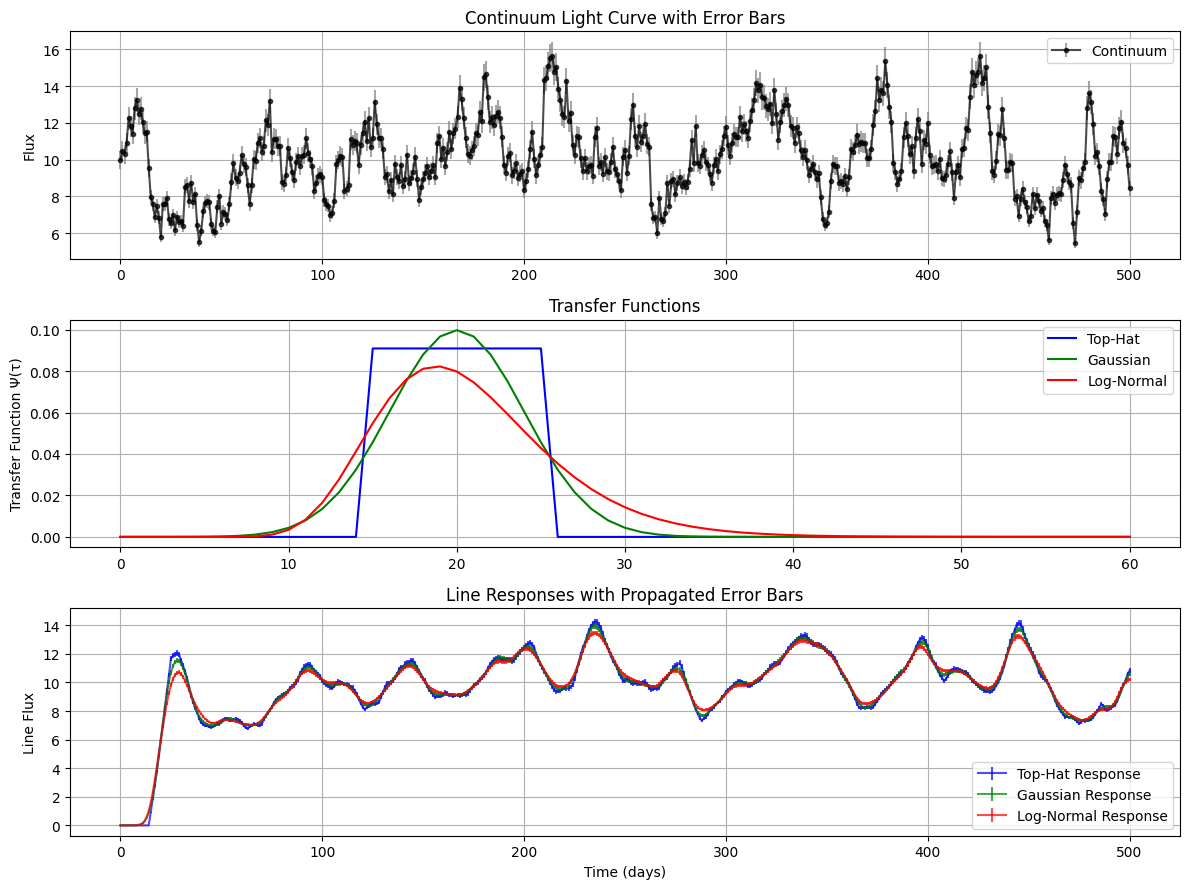

In [8]:
# Create subplots
fig, axs = plt.subplots(3, 1, figsize=(12, 9), sharex=False)

# Plot continuum with error bars
axs[0].errorbar(t, c, yerr=c_err, fmt='o-', markersize=3, label='Continuum', color='black', ecolor='grey', alpha=0.7)
axs[0].set_ylabel('Flux')
axs[0].set_title('Continuum Light Curve with Error Bars')
axs[0].legend()
axs[0].grid(True)

# Plot transfer functions
axs[1].plot(tau_grid, psi_top_hat, label='Top-Hat', color='blue')
axs[1].plot(tau_grid, psi_gaussian, label='Gaussian', color='green')
axs[1].plot(tau_grid, psi_lognormal, label='Log-Normal', color='red')
axs[1].set_ylabel('Transfer Function Ψ(τ)')
axs[1].set_title('Transfer Functions')
axs[1].legend()
axs[1].grid(True)

# Plot line responses with error bars
axs[2].errorbar(t, line_top_hat, yerr=line_top_hat_err, label='Top-Hat Response', fmt='-', color='blue', alpha=0.7)
axs[2].errorbar(t, line_gaussian, yerr=line_gaussian_err, label='Gaussian Response', fmt='-', color='green', alpha=0.7)
axs[2].errorbar(t, line_lognormal, yerr=line_lognormal_err, label='Log-Normal Response', fmt='-', color='red', alpha=0.7)
axs[2].set_xlabel('Time (days)')
axs[2].set_ylabel('Line Flux')
axs[2].set_title('Line Responses with Propagated Error Bars')
axs[2].legend()
axs[2].grid(True)

plt.tight_layout()
plt.savefig('transfer_function_plot.png')
plt.show()

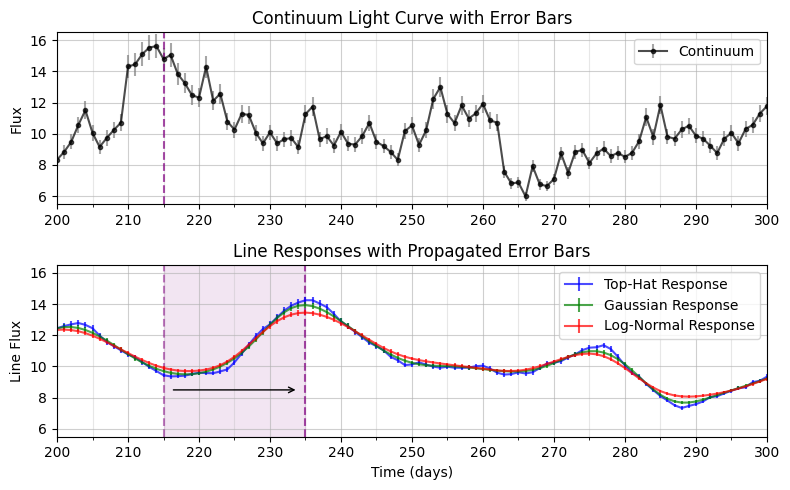

In [44]:
# Create subplots
fig, axs = plt.subplots(2, 1, figsize=(8, 5), sharex=False)

xl, xm, yl, ym = 200, 300, 5.5, 16.5

# Plot continuum with error bars
axs[0].errorbar(t, c, yerr=c_err, fmt='o-', markersize=3, label='Continuum', color='black', ecolor='grey', alpha=0.7)
axs[0].vlines(215, yl, ym, ls='dashed', color='purple', alpha=0.7)
axs[0].set_ylabel('Flux')
axs[0].set_title('Continuum Light Curve with Error Bars')

# Plot line responses with error bars
axs[1].fill_between([215,235], yl, ym, alpha=0.1, color='purple')
axs[1].vlines([215,235], yl, ym, ls='dashed', color='purple', alpha=[0.5, 0.7])
axs[1].annotate("", xytext=(216,8.5), xy=(234, 8.5), arrowprops=dict(arrowstyle="->"), c='purple')
axs[1].errorbar(t, line_top_hat, yerr=line_top_hat_err, label='Top-Hat Response', fmt='-', color='blue', alpha=0.7)
axs[1].errorbar(t, line_gaussian, yerr=line_gaussian_err, label='Gaussian Response', fmt='-', color='green', alpha=0.7)
axs[1].errorbar(t, line_lognormal, yerr=line_lognormal_err, label='Log-Normal Response', fmt='-', color='red', alpha=0.7)
axs[1].set_xlabel('Time (days)')
axs[1].set_ylabel('Line Flux')
axs[1].set_title('Line Responses with Propagated Error Bars')

for _ in axs:
    _.set_xlim(xl, xm)
    _.set_ylim(yl, ym)
    _.set_xticks(np.arange(200, 301, 10))
    _.set_xticks(np.arange(200, 301, 5), minor=True)
    _.grid(which='minor', alpha=0.3)
    _.grid(which='major', alpha=0.6)
    _.legend()
    
plt.tight_layout()
plt.savefig('transfer_function_plot_zoom.png')
plt.show()

In [10]:
def keep_indices(num, downsample_rate=0.3):
    # decide global kept indices at random from 
    kept = np.random.choice(num, int(downsample_rate * num), replace=False)
    kept.sort()
    return kept

indices = keep_indices(len(t))

def downsample(t, line, err, indices=indices):
    # downsamples by creating a new array of "chosen" indices in the t and line arrays
    downsampled_t = t[indices]
    downsampled_line = line[indices]
    downsampled_err = err[indices]
    return downsampled_t, downsampled_line, downsampled_err


def seasonal_mask(t, line, err, observing_window=(0, 180), year_length=365.25):
    """
    Apply a seasonal mask across multiple years to simulate observability constraints.

    Args:
        t (array-like): Time array in days.
        line (array-like): Light curve values.
        err (array-like): Error values.
        observing_window (tuple): Start and end day of the observing season (e.g., (0, 180) for Jan-Jun).
        year_length (float): Length of a year in days (default is 365.25).

    Returns:
        masked_t, masked_line, masked_err: Arrays with only seasonally observable data.
    """
    t = np.asarray(t)
    season_start, season_end = observing_window

    # Compute day-of-year for each time point
    day_of_year = np.mod(t, year_length)

    # Create mask for times within the observing window
    mask = (day_of_year >= season_start) & (day_of_year <= season_end)

    return t[mask], line[mask], err[mask]

def make_realistic(t, line, err, downsample_rate=0.3, observing_window=(0, 180), indices=indices):
    """
    Apply seasonal mask and downsampling to simulate realistic observations.

    Args:
        t (array-like): Time array.
        line (array-like): Light curve values.
        err (array-like): Error values.
        downsample_rate (float): Fraction of data to keep after masking.
        observing_window (tuple): Seasonal observing window in days.

    Returns:
        realistic_t, realistic_line, realistic_err: Downsampled and seasonally masked arrays.
    """
    # Apply seasonal mask
    t_masked, line_masked, err_masked = seasonal_mask(t, line, err, observing_window)

    # Downsample
    if len(t_masked) == 0:
        return np.array([]), np.array([]), np.array([])

    indices = keep_indices(len(t_masked), downsample_rate)
    realistic_t, realistic_line, realistic_err = downsample(t_masked, line_masked, err_masked, indices)

    return realistic_t, realistic_line, realistic_err

tds, cds, cds_err = downsample(t, c, c_err)
tds_th, lds_th, lds_th_err = downsample(t, line_top_hat, line_top_hat_err)
tds_gauss, lds_gauss, lds_gauss_err = downsample(t, line_gaussian, line_gaussian_err)
tds_ln, lds_ln, lds_lh_err = downsample(t, line_lognormal, line_lognormal_err)

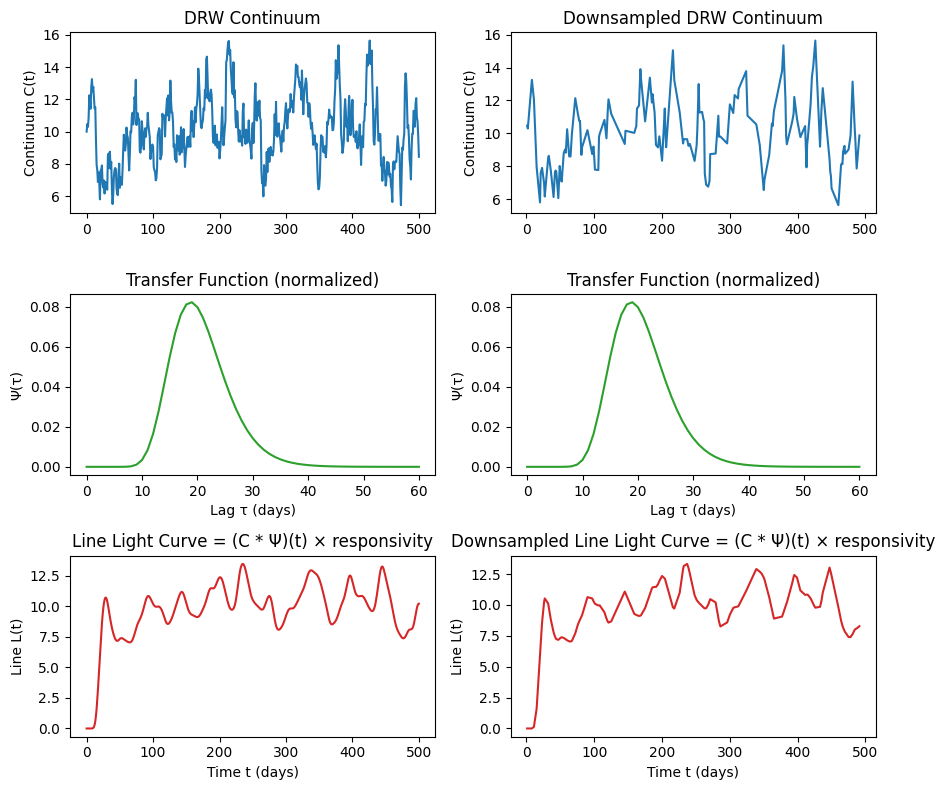

In [32]:
# single-plot
fig, axs = plt.subplots(3, 2, figsize=(9, 8), sharex=False)
axs[0, 0].plot(t, c, color='tab:blue', lw=1.5)
axs[0, 0].set_ylabel("Continuum C(t)")
axs[0, 0].set_title("DRW Continuum")

axs[1, 0].plot(tau_grid, psi_lognormal, color='tab:green', lw=1.5)
axs[1, 0].set_xlabel("Lag τ (days)")
axs[1, 0].set_ylabel("Ψ(τ)")
axs[1, 0].set_title("Transfer Function (normalized)")

axs[2, 0].plot(t, line_lognormal, color='tab:red', lw=1.5)
axs[2, 0].set_xlabel("Time t (days)")
axs[2, 0].set_ylabel("Line L(t)")
axs[2, 0].set_title("Line Light Curve = (C * Ψ)(t) × responsivity")

axs[0, 1].plot(tds, cds, color='tab:blue')
axs[0, 1].set_ylabel("Continuum C(t)")
axs[0, 1].set_title("Downsampled DRW Continuum")

axs[1, 1].plot(tau_grid, psi_lognormal, color='tab:green', lw=1.5)
axs[1, 1].set_xlabel("Lag τ (days)")
axs[1, 1].set_ylabel("Ψ(τ)")
axs[1, 1].set_title("Transfer Function (normalized)")

axs[2, 1].plot(tds_ln, lds_ln, color='tab:red', lw=1.5)
axs[2, 1].set_xlabel("Time t (days)")
axs[2, 1].set_ylabel("Line L(t)")
axs[2, 1].set_title("Downsampled Line Light Curve = (C * Ψ)(t) × responsivity")

plt.tight_layout()
plt.show()

In [ ]:
float_fmt = "%.6f"
cut_start, cut_end = 30, -1
# saves the continuum light curve
np.savetxt('Synth Data/cont.txt', np.stack((t, c, c_err), axis=-1)[cut_start:cut_end, :], delimiter=' ', fmt=float_fmt)

# saves the top-hat transfer function and its convolution
np.savetxt('Synth Data/top_hat_trans.txt', np.stack((tau_grid, psi_top_hat), axis=-1), delimiter=' ', fmt=float_fmt)
np.savetxt('Synth Data/top_hat_conv.txt', np.stack((t, line_top_hat, line_top_hat_err), axis=-1)[cut_start:cut_end, :], delimiter=' ', fmt=float_fmt)

# gaussian
np.savetxt('Synth Data/gaussian_trans.txt', np.stack((tau_grid, psi_gaussian), axis=-1), delimiter=' ', fmt=float_fmt)
np.savetxt('Synth Data/gaussian_conv.txt', np.stack((t, line_gaussian, line_gaussian_err), axis=-1)[cut_start:cut_end, :], delimiter=' ', fmt=float_fmt)

# log-normal
np.savetxt('Synth Data/lognorm_trans.txt', np.stack((tau_grid, psi_lognormal), axis=-1), delimiter=' ', fmt=float_fmt)
np.savetxt('Synth Data/lognorm_conv.txt', np.stack((t, line_lognormal, line_lognormal_err), axis=-1)[cut_start:cut_end, :], delimiter=' ', fmt=float_fmt)

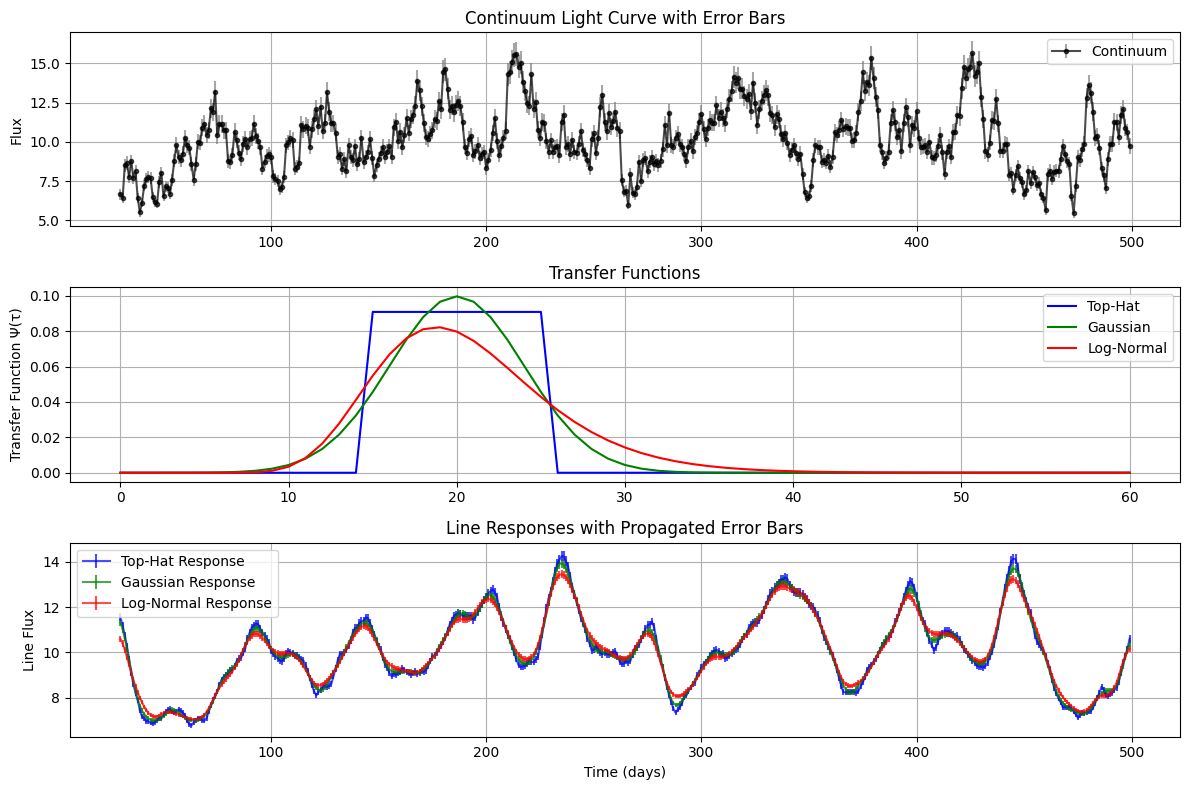

In [ ]:
# Plots from loading the files to check against above plots.
# Load data from .txt files, skipping headers
_t, _c, _c_err = np.loadtxt('Synth Data/cont.txt', delimiter=' ', unpack=True)
_tau_top, _psi_top = np.loadtxt('Synth Data/top_hat_trans.txt', delimiter=' ', unpack=True)
_tau_gauss, _psi_gauss = np.loadtxt('Synth Data/gaussian_trans.txt', delimiter=' ', unpack=True)
_tau_log, _psi_log = np.loadtxt('Synth Data/lognorm_trans.txt', delimiter=' ', unpack=True)

_, _line_top, _line_top_err = np.loadtxt('Synth Data/top_hat_conv.txt', delimiter=' ', unpack=True)
_, _line_gauss, _line_gauss_err = np.loadtxt('Synth Data/gaussian_conv.txt', delimiter=' ', unpack=True)
_, _line_log, _line_log_err = np.loadtxt('Synth Data/lognorm_conv.txt', delimiter=' ', unpack=True)

# Create subplots
fig, axs = plt.subplots(3, 1, figsize=(12, 8), sharex=False)

# Plot continuum with error bars
axs[0].errorbar(_t, _c, yerr=_c_err, fmt='o-', markersize=3, label='Continuum', color='black', ecolor='grey', alpha=0.7)
axs[0].set_ylabel('Flux')
axs[0].set_title('Continuum Light Curve with Error Bars')
axs[0].legend()
axs[0].grid(True)

# Plot transfer functions
axs[1].plot(_tau_top, _psi_top, label='Top-Hat', color='blue')
axs[1].plot(_tau_gauss, _psi_gauss, label='Gaussian', color='green')
axs[1].plot(_tau_log, _psi_log, label='Log-Normal', color='red')
axs[1].set_ylabel('Transfer Function Ψ(τ)')
axs[1].set_title('Transfer Functions')
axs[1].legend()
axs[1].grid(True)

# Plot line responses with error bars
axs[2].errorbar(_t, _line_top, yerr=_line_top_err, label='Top-Hat Response', fmt='-', color='blue', alpha=0.7)
axs[2].errorbar(_t, _line_gauss, yerr=_line_gauss_err, label='Gaussian Response', fmt='-', color='green', alpha=0.7)
axs[2].errorbar(_t, _line_log, yerr=_line_log_err, label='Log-Normal Response', fmt='-', color='red', alpha=0.7)
axs[2].set_xlabel('Time (days)')
axs[2].set_ylabel('Line Flux')
axs[2].set_title('Line Responses with Propagated Error Bars')
axs[2].legend()
axs[2].grid(True)

plt.tight_layout()
plt.savefig('transfer_function_plot.png')
plt.show()